# Chapitre 4 — EDA diagnostique et qualité des données

**Durée estimée : 8-10 heures**

---

## Objectifs d'apprentissage

À la fin de ce chapitre, vous serez capable de :

1. **Distinguer** l'EDA diagnostique (trouver les problèmes) de l'EDA analytique (comprendre les patterns)
2. **Évaluer** la qualité des données selon les 6 dimensions standardisées
3. **Détecter** les valeurs manquantes, doublons et outliers avec les outils pandas appropriés
4. **Documenter** les problèmes identifiés dans une checklist de qualité priorisée

---

## 4.7 Visualisations de diagnostic

### 1️⃣ Introduction
Matplotlib est la bibliothèque principale en Python pour tracer des graphiques.
Elle permet de créer des graphiques simples comme des lignes, des histogrammes, des barres, mais aussi des graphiques plus complexes avec plusieurs axes et personnalisations.

In [2]:
#On l’importe ainsi 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Pour des graphiques inline dans Jupyter
%matplotlib inline

### 2️⃣ Principe de base : figure et axes

Matplotlib fonctionne avec 2 concepts importants :

	1.	Figure → c’est le conteneur global, comme une page blanche, pour un ou plusieurs graphiques. Contient tous les axes, titres, labels et objets graphiques.

	2.	Axes → un graphique à l’intérieur de la figure, avec ses propres axes X et Y. Chaque ax correspond à un graphique indépendant dans la figure.

***Anatomie d'un graphique Matplotlib***

```
┌─────────────────────────────────────────────────────────┐
│  Figure (conteneur global)                              │
│  ┌───────────────────────────────────────────────────┐ │
│  │  Axes (zone de tracé)                  ┌───────┐  │ │
│  │                                        │Legend │  │ │
│  │       Title                            └───────┘  │ │
│  │  ┌────────────────────────────────────────────┐  │ │
│  │  │                    .                       │  │ │
│  │ Y│                 .     .                    │  │ │
│  │ l│              .           .                 │  │ │
│  │ a│           .                 .              │  │ │
│  │ b│        .                       .           │  │ │
│  │ e│     .                             .        │  │ │
│  │ l│  .                                   .     │  │ │
│  │  └────────────────────────────────────────────┘  │ │
│  │              X label                             │ │
│  └───────────────────────────────────────────────────┘ │
└─────────────────────────────────────────────────────────┘
```

#### Graphiques de base

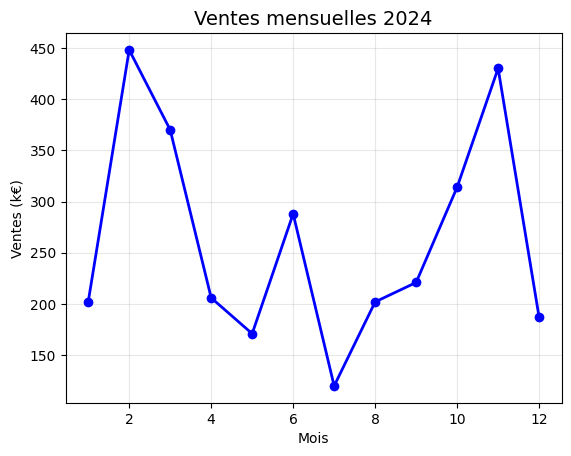

In [9]:
# Données exemple
np.random.seed(42)
x = np.arange(1, 13)
y = np.random.randint(100, 500, 12)

# LINE CHART
plt.plot(x, y, marker='o', linestyle='-', color='blue', linewidth=2)

# Ajouter un titre et des labels
plt.title('Ventes mensuelles 2024', fontsize=14)
plt.xlabel('Mois')
plt.ylabel('Ventes (k€)')
plt.grid(True, alpha=0.3)

# Afficher le graphique
plt.show()

# Explications :
# plt.plot(x, y) → trace une ligne reliant les points (x[i], y[i]).
# plt.title() → titre du graphique
# plt.xlabel() / plt.ylabel() → noms des axes
# plt.show() → affiche le graphique à l’écran

# 💡 Important : chaque graphique que tu crées avec plt.plot() va s’ajouter à la figure actuelle jusqu’à ce que tu fasses plt.show().

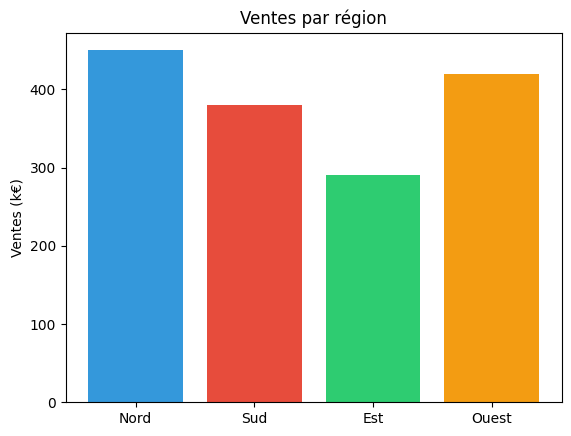

In [3]:
# BAR CHART
categories = ['Nord', 'Sud', 'Est', 'Ouest']
valeurs = [450, 380, 290, 420]

plt.bar(categories, valeurs, color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'])
plt.title('Ventes par région')
plt.ylabel('Ventes (k€)')
plt.show()

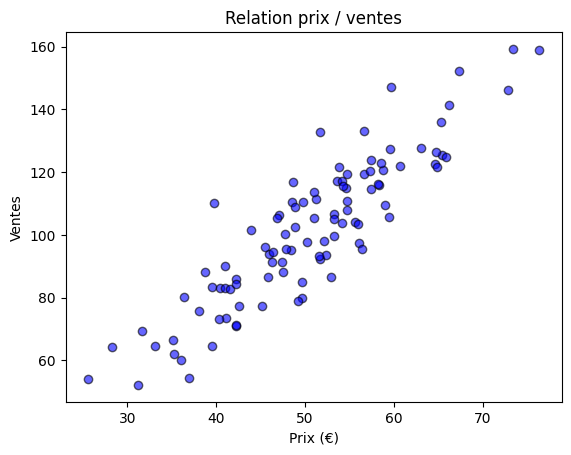

In [4]:
# SCATTER PLOT
x = np.random.normal(50, 10, 100)
y = 2 * x + np.random.normal(0, 10, 100)

plt.scatter(x, y, alpha=0.6, c='blue', edgecolors='black')
plt.title('Relation prix / ventes')
plt.xlabel('Prix (€)')
plt.ylabel('Ventes')
plt.show()

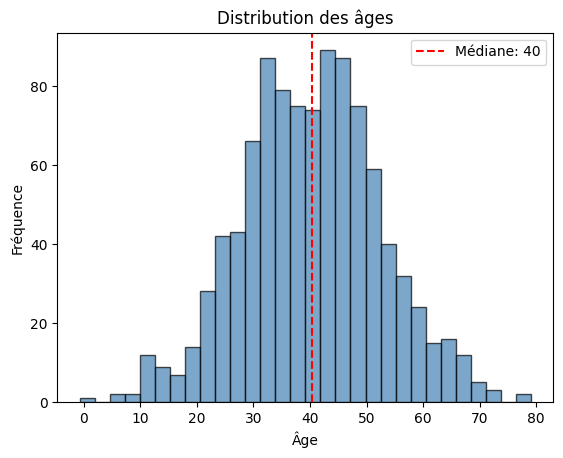

In [6]:
# HISTOGRAM
ages = np.random.normal(40, 12, 1000)

plt.hist(ages, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
plt.title('Distribution des âges')
plt.xlabel('Âge')
plt.ylabel('Fréquence')
plt.axvline(np.median(ages), color='red', linestyle='--', label=f'Médiane: {np.median(ages):.0f}')
plt.legend()
plt.show()

### 3️⃣ Créer et stocker des figures et des sous-graphes  (subplots)

Subplots (plt.subplots()) :

•	Sert à créer plusieurs axes dans une figure.

•	Retourne toujours : fig, ax (ou fig, axes)

•	Si 1 graphique → ax est un objet unique

•	Si plusieurs graphiques → axes est une liste ou un tableau d’objets Axes

Deux rôles principaux de fig, ax = plt.subplots()

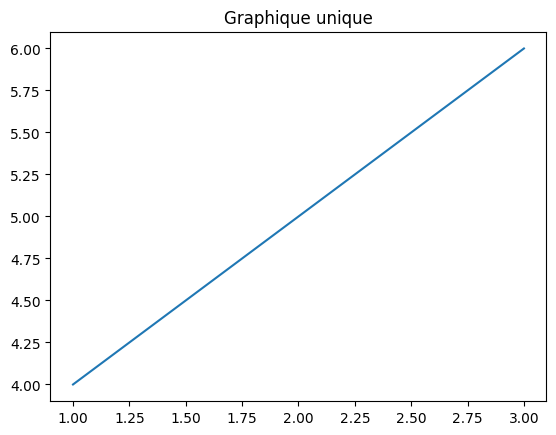

In [25]:
# Cas pratique : 1 seul graphique

fig1, ax = plt.subplots()  # 1 figure, 1 axe
ax.plot([1,2,3],[4,5,6])
ax.set_title("Graphique unique")
plt.show()  # Affiche le graphique

# fig → représente la figure entière
# ax → représente les axes ou le graphique spécifique

# Pourquoi utiliser subplots même pour 1 graphique ?
#	Pour stocker la figure et l’axe dans des variables → tu peux modifier ou réafficher plus tard.
#	Recommandé pour tout workflow sérieux ou diagnostic exploratoire.

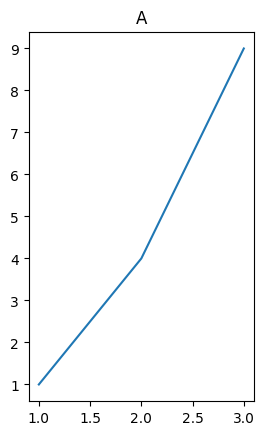

In [4]:
plt.subplot(1, 2, 1)
plt.plot([1, 2, 3], [1, 4, 9])
plt.title("A")

plt.show()

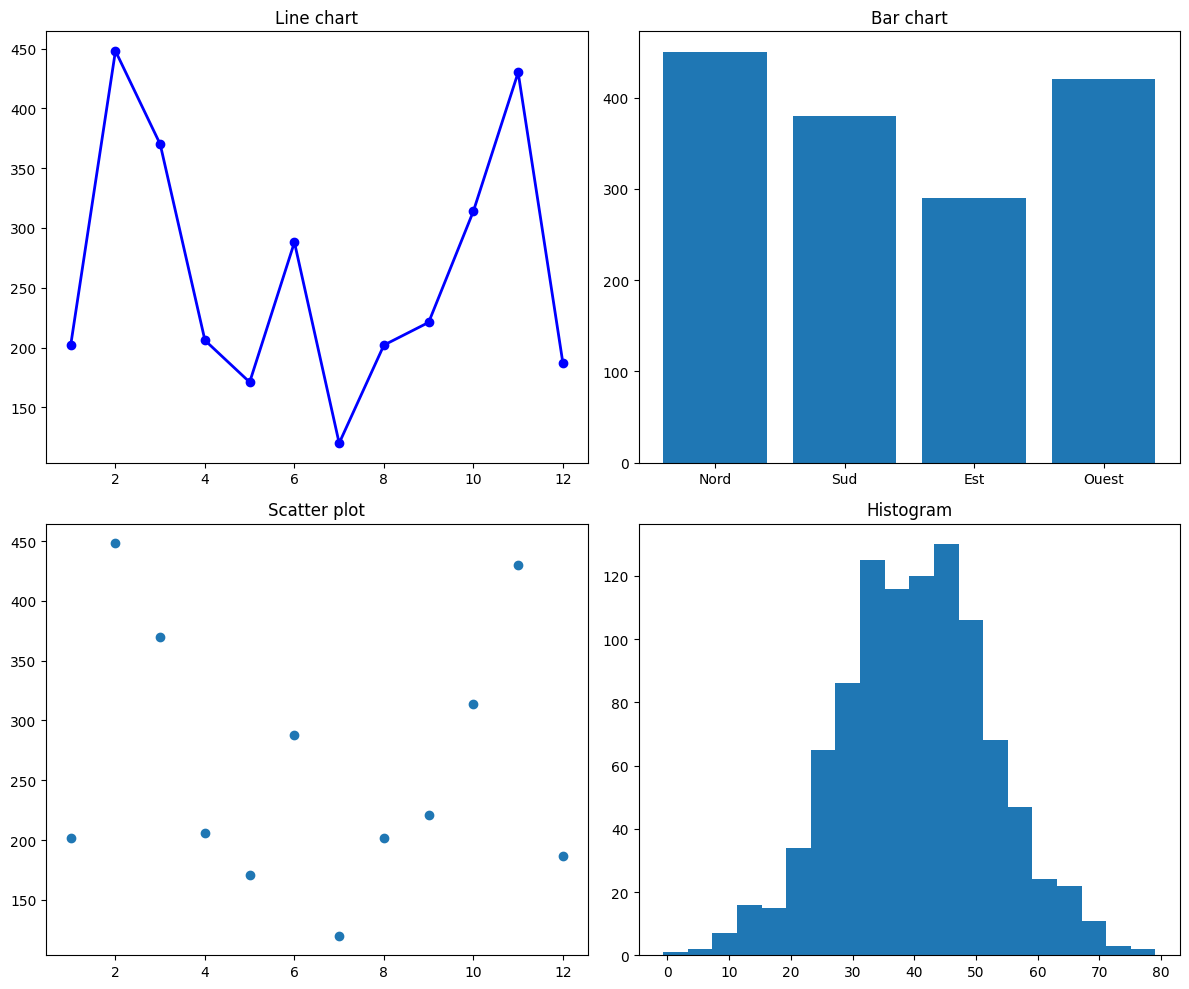

In [ ]:
# Cas pratique : plusieurs graphiques dans une figure

fig2, axes = plt.subplots(2, 2, figsize=(12, 10)) # 2 ligne, 2 colonnes
# Ici, fig est la figure créée, donc tu n’as pas besoin de plt.figure() avant.

# Graphique 1
axes[0, 0].plot(x, y, marker='o', linestyle='-', color='blue', linewidth=2)
axes[0, 0].set_title('Line chart')

# Graphique 2
axes[0, 1].bar(categories, valeurs)
axes[0, 1].set_title('Bar chart')

# Graphique 3
axes[1, 0].scatter(x, y)
axes[1, 0].set_title('Scatter plot')

# Graphique 4
axes[1, 1].hist(ages, bins=20)
axes[1, 1].set_title('Histogram')

plt.tight_layout() # Ajuste l’espacement entre subplots
plt.show()

# axes est une liste/tableau d’Axes → chaque subplot est accessible par axes[i].
# axes[i].set_title() → titre spécifique pour chaque graphique
# figsize=(largeur, hauteur) → taille globale de la figure
# Tu ne peux pas faire axes.plot() directement, il faut choisir le subplot.
# Utile pour comparer plusieurs variables côte à côte (diagnostic exploratoire).
# dans axes la ligne commence à 0 

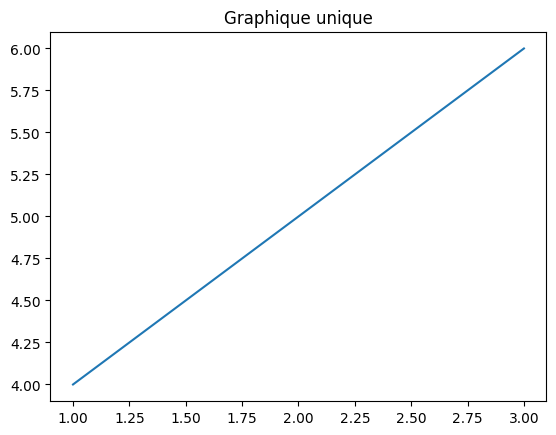

In [27]:
# Réafficher plusieurs figures
fig1

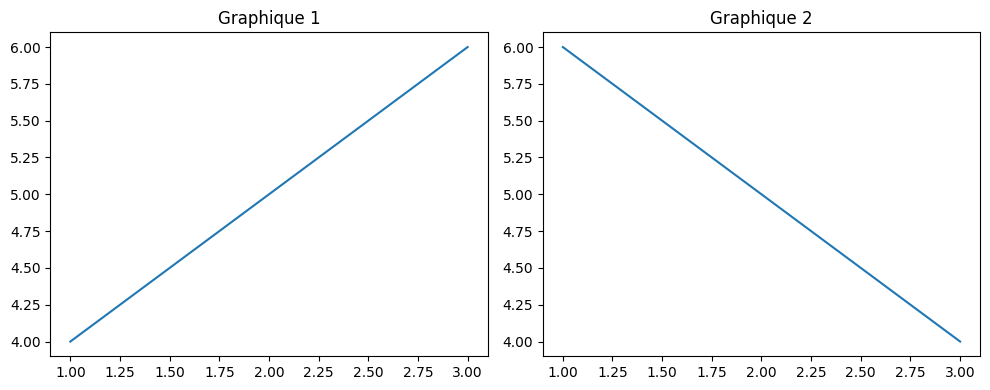

In [28]:
# Réafficher plusieurs figures
fig2
# Chaque figure est indépendante, et tu peux réafficher n’importe laquelle.

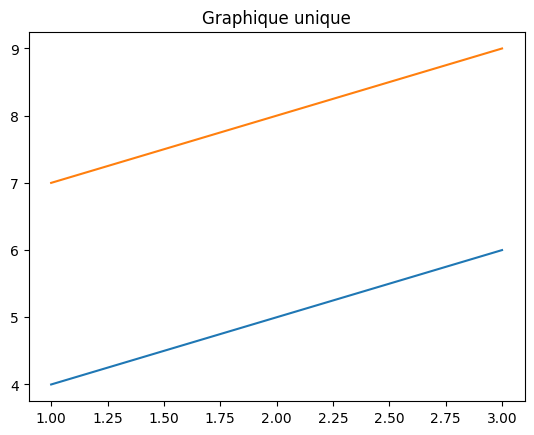

In [29]:
# Réafficher plusieurs figures
ax.plot([1,2,3],[7,8,9])  # ajoute une ligne
fig1  # réaffiche avec la nouvelle ligne

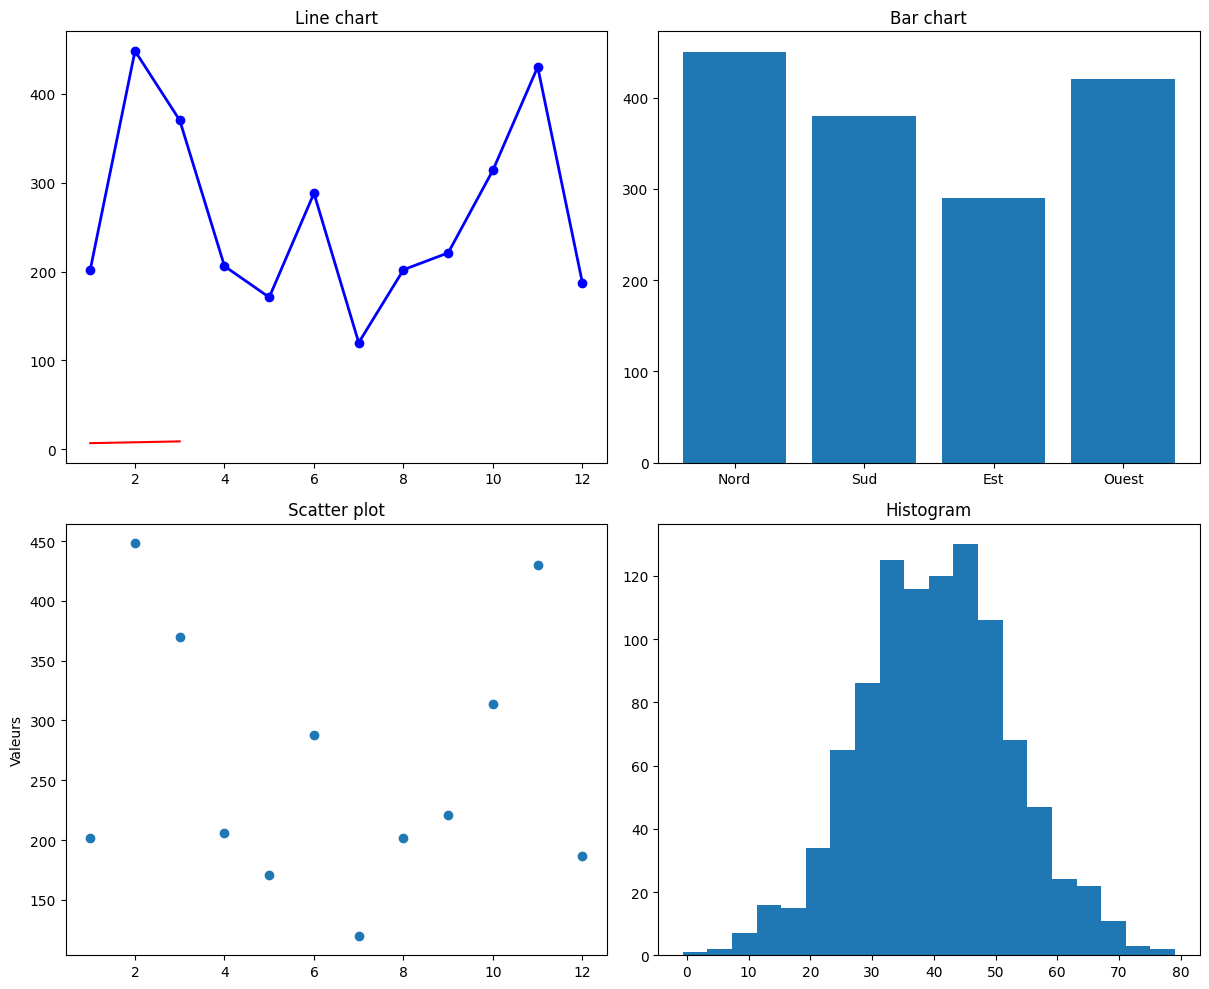

In [12]:
# Réafficher plusieurs figures
axes[0, 0].plot([1,2,3],[7,8,9], color='red')  # ajoute une ligne au premier subplot
axes[1, 0].set_ylabel('Valeurs')                # modifie l’axe Y du deuxième subplot
fig2

In [ ]:
# Efface juste le contenu de l'axe, mais garde la place dans la figure
axes[0, 0].clear()

# Puis ajouter un nouveau graphique au même endroit
axes[0, 0].hist([1, 2, 3, 4, 5], bins=5)
axes[0, 0].set_title('Nouveau graphique')
fig2

---

### 🤖 IA : Générer du code Matplotlib

**Prompt efficace :**

```
Génère du code Matplotlib pour créer :
- Un graphique à barres horizontales
- Données : {'Python': 85, 'SQL': 72, 'R': 45, 'Excel': 90}
- Triées par valeur décroissante
- Couleurs dégradées du vert (max) au rouge (min)
- Titre : "Compétences de l'équipe Data"
- Labels sur les barres
- Figure de 10x6 pouces
```

**Différence avec plt.plot() simple**

```python
plt.plot([1,2,3],[4,5,6])
plt.title('Graphique rapide')
plt.show()
```

	•	Fonctionne pour un graphique rapide et jetable.
	•	Tu ne peux pas réafficher facilement si tu crées d’autres graphiques après.
	•	Pas de stockage dans fig ou ax → modification ou réutilisation limitée.

**Bonnes pratiques**

	1.	Toujours utiliser fig, ax = plt.subplots(), même pour 1 graphique → ça permet de stocker et réutiliser.

	2.	Pour plusieurs graphiques dans la même figure, passer par subplots(nrows, ncols) → tu auras axes[i]. (commence à 0) (si 1 seule ligne, alors axes[ncol] pas axes[nligne, ncol])

	3.	Pour réafficher une figure existante :
	•	Script Python : plt.figure(fig.number); plt.show()
	•	Notebook : juste fig ou plt.show()

	4.	Ne jamais utiliser fig.show() dans un notebook → provoque un warning (FigureCanvasAgg non interactif).

	5.	Ajouter des graphiques après coup : travailler toujours sur l’objet ax correspondant.

```markdown 
Figure (fig) : le conteneur global
 ├─ Axes (ax) : premier graphique
 │    └─ ax.plot() / ax.set_title() / ax.set_xlabel() ...
 └─ Axes (ax) : deuxième graphique (si subplot)
      └─ axes[1].plot() ...
```

***Résumé des commandes essentielles***

| Action                | Commande                                 |Commande fig / ax                                       |
|----------------------|-------------------------------------------|--------------------------------------------------------|
| Créer une figure     | `plt.figure(figsize=(x, y))`              | `fig, ax = plt.subplots(figsize=(x, y))`               |
| Tracer une ligne     | `plt.plot(x, y)`                          | `ax.plot(x, y)`                                        |
| Histogramme          | `plt.hist(data)`                          | `ax.hist(data)`                                        |
| Barres               | `plt.bar(categories, values)`             | `ax.bar(categories, values)`                           |
| Points               | `plt.scatter(x, y)`                       | `ax.scatter(x, y)`                                     |
| Boxplot              | `plt.boxplot(data)`                       | `ax.boxplot(data)`                                     |
| Ajouter titre        | `plt.title('Titre')`                      | `ax.set_title('Titre')`                                |
| Ajouter labels axes  | `plt.xlabel('X'), plt.ylabel('Y')`        | `ax.set_title('Titre')`                                |
| Grille               | `plt.grid(True)`                          | `ax.grid(True)`                                        |
| Subplots             | `fig, axes = plt.subplots(n_lignes, n_colonnes)`| Idem                                             |
| Accéder à un axe     | `axes[i, j]` ou `axes[i]` | Idem                                                                   |
| Sauvegarder          | `plt.savefig('nom.png')`                  | `fig.savefig('nom.png')`                               |
| Afficher la figure   | `plt.show()` | Idem                                                                                |